In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
order_payments = pd.read_csv("olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")

In [3]:
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(order_items, on='order_id', how='left')
df = df.merge(order_payments, on='order_id', how='left')
df = df.merge(order_reviews, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(sellers, on='seller_id', how='left')

In [4]:
df.isnull().sum().sort_values(ascending = False)

review_comment_title             105154
review_comment_message            68898
order_delivered_customer_date      3421
product_name_lenght                2542
product_category_name              2542
product_photos_qty                 2542
product_description_lenght         2542
order_delivered_carrier_date       2086
review_answer_timestamp             997
review_creation_date                997
review_id                           997
review_score                        997
product_width_cm                    853
product_length_cm                   853
product_weight_g                    853
product_height_cm                   853
freight_value                       833
seller_state                        833
price                               833
shipping_limit_date                 833
seller_id                           833
order_item_id                       833
seller_zip_code_prefix              833
seller_city                         833
product_id                          833


In [5]:
df["review_comment_title"] = df["review_comment_title"].fillna("No reviews")
df["review_comment_message"] = df["review_comment_message"].fillna("N/A")
df['product_name_lenght'] = df['product_name_lenght'].fillna(df['product_name_lenght'].median())
df['product_description_lenght'] = df['product_description_lenght'].fillna(df['product_description_lenght'].median())
df['product_width_cm'] = df['product_width_cm'].fillna(df['product_width_cm'].median())
df['product_length_cm'] = df['product_length_cm'].fillna(df['product_length_cm'].median())
df['product_weight_g'] = df['product_weight_g'].fillna(df['product_weight_g'].median())
df['product_height_cm'] = df['product_height_cm'].fillna(df['product_height_cm'].median())
df['product_category_name']= df['product_category_name'].fillna('Unknown')
df['product_photos_qty']= df['product_photos_qty'].fillna(0)
df["seller_state"] = df["seller_state"].fillna("Unknown")
df['seller_zip_code_prefix']= df['seller_zip_code_prefix'].fillna("00000")
df = df.dropna(subset=['price', 'product_id', 'seller_id', 'order_item_id', 'payment_value', 'payment_type', 'payment_installments', 'payment_sequential'])

In [6]:
df.isnull().sum().sort_values(ascending = False)

order_delivered_customer_date    2588
order_delivered_carrier_date     1254
review_id                         978
review_score                      978
review_creation_date              978
review_answer_timestamp           978
order_approved_at                  15
product_description_lenght          0
review_comment_title                0
review_comment_message              0
product_category_name               0
product_name_lenght                 0
order_id                            0
product_photos_qty                  0
payment_value                       0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
seller_zip_code_prefix              0
seller_city                         0
product_weight_g                    0
payment_type                        0
payment_installments                0
customer_state                      0
order_status                        0
order_purchase_timestamp            0
order_estima

In [7]:
df.to_csv("olist_merged_cleaned.csv", index=False)

In [8]:
df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
order_item_id                    float64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
payment_sequential               float64
payment_type                      object
payment_installments             float64
payment_value                    float64
review_id                         object
review_score                     float64
review_comment_t

In [9]:
df['order_item_id'] = df['order_item_id'].astype(int)
date_col = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date","order_delivered_customer_date","order_estimated_delivery_date","shipping_limit_date"]
for i in date_col:
    df[i] = pd.to_datetime(df[i])
df['payment_sequential'] = df['payment_sequential'].astype(int)
df['payment_installments'] = df['payment_installments'].astype(int)
df['customer_zip_code_prefix'] = df['customer_zip_code_prefix'].astype(str)
df['review_score'] = df['review_score'].astype('Int64')

In [10]:
df.select_dtypes(include = "object").columns

Index(['order_id', 'customer_id', 'order_status', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_id', 'seller_id', 'payment_type', 'review_id',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp',
       'product_category_name', 'seller_zip_code_prefix', 'seller_city',
       'seller_state'],
      dtype='object')

In [11]:
df.select_dtypes(include = "int").columns

Index(['order_item_id', 'payment_sequential', 'payment_installments',
       'review_score'],
      dtype='object')

In [12]:
df.select_dtypes(include = "float").columns

Index(['price', 'freight_value', 'payment_value', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [13]:
df.select_dtypes(include = "Int64").columns

Index(['review_score'], dtype='object')

In [14]:
df.select_dtypes(include = "datetime").columns

Index(['order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'shipping_limit_date'],
      dtype='object')

Sales Analysis

Monthly Sales Trend (2016–2018)

<Figure size 1000x600 with 0 Axes>

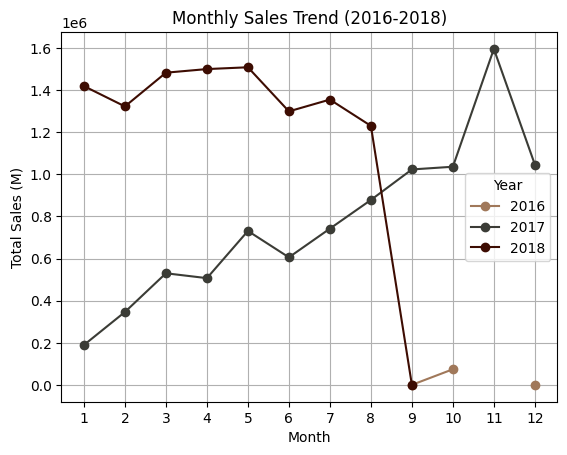

In [16]:
df["Month"] = df["order_purchase_timestamp"].dt.month
df["Year"] = df["order_purchase_timestamp"].dt.year
Monthly_sales = df.groupby(['Year', 'Month'])['payment_value'].sum().unstack(level=0)


plt.figure(figsize=(10,6))
colors = "#a0785a", "#3b3c36", "#3d0c02"
Monthly_sales.plot(marker='o', color = colors)
plt.title("Monthly Sales Trend (2016-2018)")
plt.xlabel("Month")
plt.ylabel("Total Sales (M)")
plt.xticks(range(1,13))
# plt.ticklabel_format(style='plain', axis='y')
Monthly_sales = Monthly_sales / 1000000
plt.grid(True)
plt.show()

Top Revenue-Generating Categories

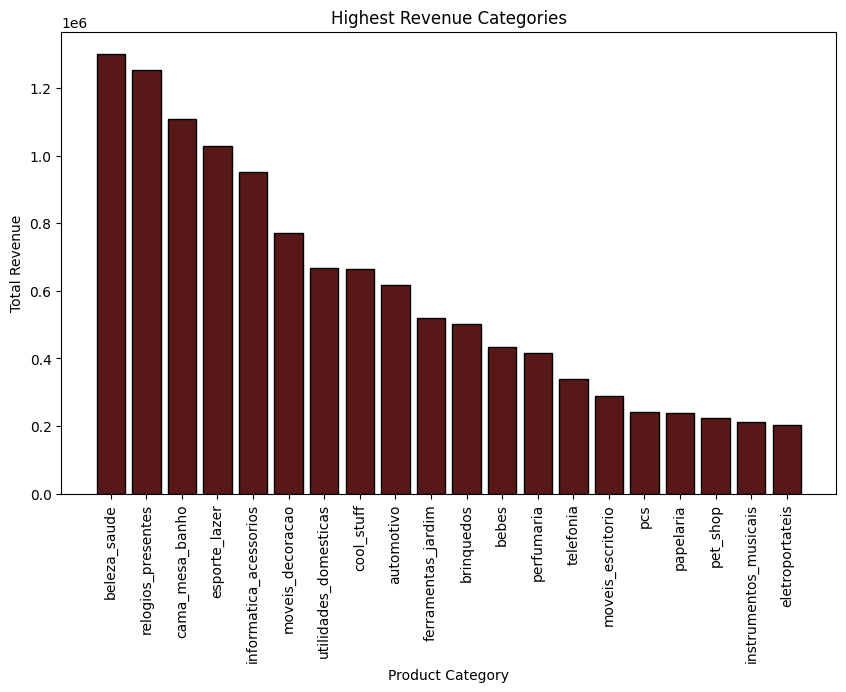

In [33]:
revenue_per_product = df.groupby('product_category_name')['price'].sum()
revenue_per_product = revenue_per_product.sort_values(ascending=False)
Top20 = revenue_per_product.head(20)

plt.figure(figsize=(10,6))
plt.bar(Top20.index, Top20.values, color = "#581818", edgecolor='black')
plt.xticks(rotation=90)
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.title("Highest Revenue Categories")
plt.show()

Top 10 Sales Representatives

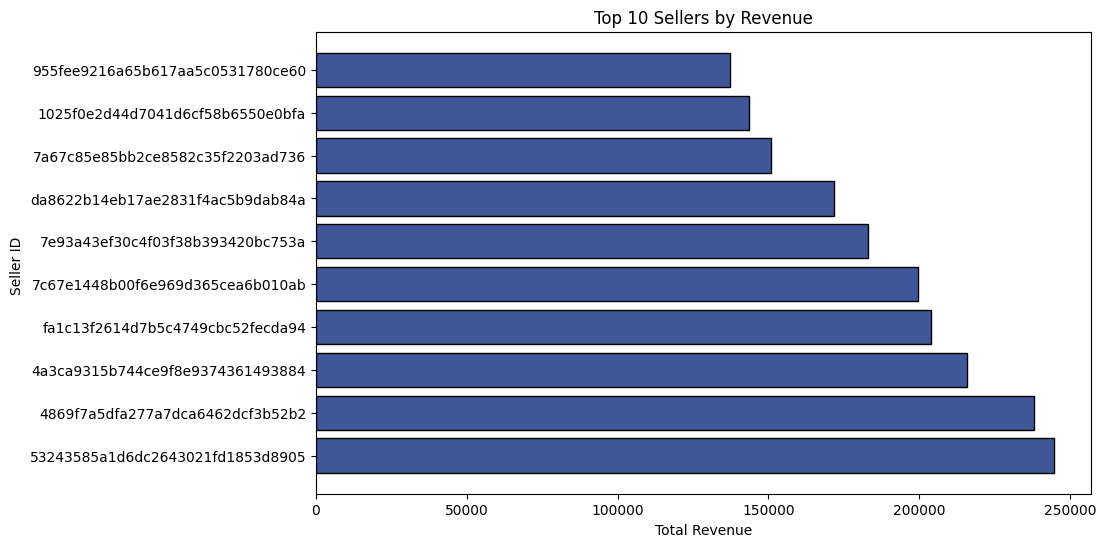

In [18]:
revenu = df.groupby("seller_id")["price"].sum()
revenu__generated = revenu.sort_values(ascending = False)
Top_10 = revenu__generated.head(10)

plt.figure(figsize=(10,6))
plt.barh(Top_10.index, Top_10.values, color = "#405899", edgecolor='black')


plt.xlabel("Total Revenue")
plt.ylabel("Seller ID ")
plt.title("Top 10 Sellers by Revenue")

plt.show()

Customer Analysis

RFM Analysis

In [19]:
# Monetary
monetary = df.groupby('customer_unique_id')['price'].sum().reset_index()
monetary = monetary.sort_values(by='price', ascending=False)
monetary = monetary.rename(columns={'price':'monetary'})


#Rececency
reference_date = df['order_delivered_customer_date'].max() + pd.Timedelta(days=1)
recency = df.groupby('customer_unique_id')['order_delivered_customer_date'].max().reset_index()
recency['Recency'] = (reference_date - recency['order_delivered_customer_date']).dt.days
recency = recency[['customer_unique_id','Recency']].sort_values(by='Recency')


#Frequency
frequency = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
frequency.columns = ['customer_unique_id', 'Frequency']
frequency = frequency.sort_values(by='Frequency', ascending=False)
frequency

,customer_unique_id,Frequency
52596,8d50f5eadf50201ccdcedfb9e2ac8455,16
23302,3e43e6105506432c953e165fb2acf44c,9
75559,ca77025e7201e3b30c44b472ff346268,7
37532,6469f99c1f9dfae7733b25662e7f1782,7
10281,1b6c7548a2a1f9037c1fd3ddfed95f33,7
...,...,...
32272,5657f9f721c16800a66c21081d46b18d,1
32271,5657dfebff5868c4dc7e8355fea865c4,1
32270,5657596addb4d7b07b32cd330614bdf8,1
32269,5656eb169546146caeab56c3ffc3d268,1


In [20]:
#Merging R, F, M into one DataFrame
rfm = recency.merge(frequency, on='customer_unique_id')
rfm = rfm.merge(monetary, on='customer_unique_id')
rfm.head()

,customer_unique_id,Recency,Frequency,monetary
0,fc0bcca3d8d90a812b707bb8e45069d6,1.0,1,26.40
1,232422c2db1f7c69daf3b0f0421ebb43,6.0,1,179.00
2,4bc530761c1b59d33d7c6cb640d3ee78,16.0,1,70.00
3,3ae68a873484afec224de126a94c5974,21.0,1,209.99
4,c9f2b70eaddf459267a9de373aaf743b,23.0,1,49.90


In [21]:
rfm['R_Scores'] = pd.qcut(rfm['Recency'],5, labels = [5,4,3,2,1], duplicates='drop')
rfm['F_Scores'] = pd.qcut(rfm['Frequency'].rank(method='first'),5, labels = [1,2,3,4,5], duplicates='drop')
rfm['M_Scores'] = pd.qcut(rfm['monetary'],5, labels = [1,2,3,4,5], duplicates='drop')
rfm.head()

,customer_unique_id,Recency,Frequency,monetary,R_Scores,F_Scores,M_Scores
0,fc0bcca3d8d90a812b707bb8e45069d6,1.0,1,26.40,5,1,1
1,232422c2db1f7c69daf3b0f0421ebb43,6.0,1,179.00,5,1,4
2,4bc530761c1b59d33d7c6cb640d3ee78,16.0,1,70.00,5,1,3
3,3ae68a873484afec224de126a94c5974,21.0,1,209.99,5,1,5
4,c9f2b70eaddf459267a9de373aaf743b,23.0,1,49.90,5,1,2


In [22]:
rfm['rfm_Score'] = rfm['R_Scores'].astype(str) + rfm['F_Scores'].astype(str) + rfm['M_Scores'].astype(str)

#Customer Segmentation
def segment_customer(row):
    if row['R_Scores'] >= 4 and row['F_Scores'] >= 4 and row['M_Scores'] >= 4:
        return 'Platinum'
    elif row['R_Scores'] >= 4 and row['F_Scores'] >= 3:
        return 'Loyal Customers'
    elif row['R_Scores'] <= 2 and row['F_Scores'] >= 3:
        return 'At Risk'
    elif row['R_Scores'] <= 2 and row['F_Scores'] <= 2:
        return 'Lost Customers'
    else:
        return 'Potential'

In [23]:
rfm['Customer_Segmentations'] = rfm.apply(segment_customer, axis =1)
rfm['Customer_Segmentations'].value_counts()

Customer_Segmentations
Potential          57098
At Risk            37049
Platinum             996
Loyal Customers      276
Name: count, dtype: int64

In [24]:
Summary = rfm.groupby('Customer_Segmentations').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'monetary': 'mean',
    'customer_unique_id': 'count'
}).rename(columns={'customer_unique_id': 'Customer_Count'})

Summary

,Recency,Frequency,monetary,Customer_Count
Customer_Segmentations,,,,
At Risk,432.021242,1.030284,150.535755,37049
Loyal Customers,128.391304,2.032609,76.308732,276
Platinum,128.758032,2.185743,350.069086,996
Potential,171.257550,1.011524,145.830598,57098


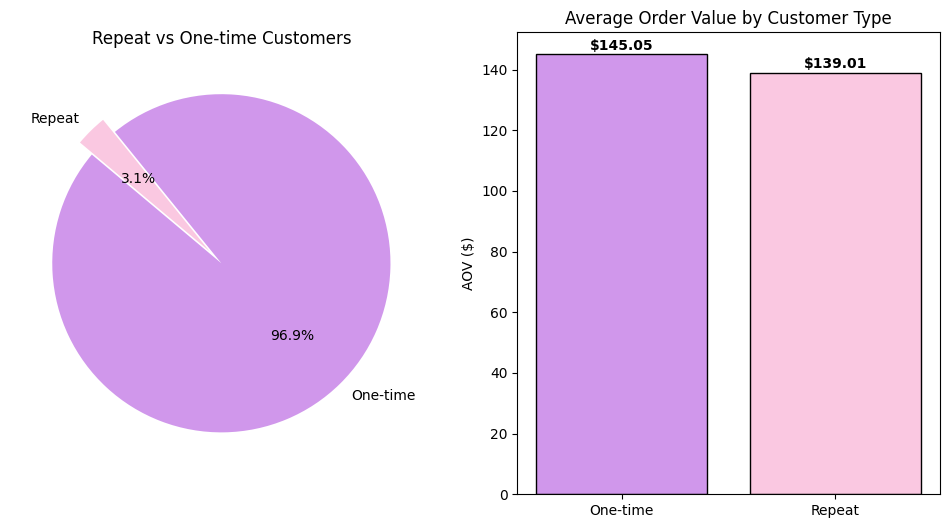

In [25]:
rfm['Customer_Type'] = rfm['Frequency'].apply(lambda x: "Repeat" if x > 1 else "One-time")
rfm['AOV'] = rfm['monetary'] / rfm['Frequency']

customer_counts = rfm['Customer_Type'].value_counts()


aov_summary = rfm.groupby('Customer_Type')['AOV'].mean()


fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Pie Chart
colors = ["#d097eb", "#f585bd73"]
explode = [0, 0.1]  
axes[0].pie(customer_counts, labels=customer_counts.index, autopct='%1.1f%%',
            colors=colors, explode=explode, startangle=140)
axes[0].set_title('Repeat vs One-time Customers')

# Bar Chart
bars = axes[1].bar(aov_summary.index, aov_summary.values, color=["#d097eb", "#f585bd73"], edgecolor='black')
axes[1].set_title('Average Order Value by Customer Type')
axes[1].set_ylabel('AOV ($)')
axes[1].bar_label(bars, labels=[f"${v:.2f}" for v in aov_summary.values], padding=1, fontsize=10, fontweight='bold')

plt.show() 

In [26]:
def simplify_segment(row):
    if row['Customer_Segmentations'] in ['Platinum', 'Loyal Customers']:
        return 'High Value'
    elif row['Customer_Segmentations'] in ['At Risk', 'Lost Customers']:
        return 'Low Value / At Risk'
    else:
        return 'Potential'

rfm['Simple_Segment'] = rfm.apply(simplify_segment, axis=1)
d = rfm.groupby("Simple_Segment").agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'monetary': 'mean',
    'customer_unique_id': 'count'
}).rename(columns={'customer_unique_id': 'Customer_Count'})
print(d)

                        Recency  Frequency    monetary  Customer_Count
Simple_Segment                                                        
High Value           128.678459   2.152516  290.668255            1272
Low Value / At Risk  432.021242   1.030284  150.535755           37049
Potential            171.257550   1.011524  145.830598           57098


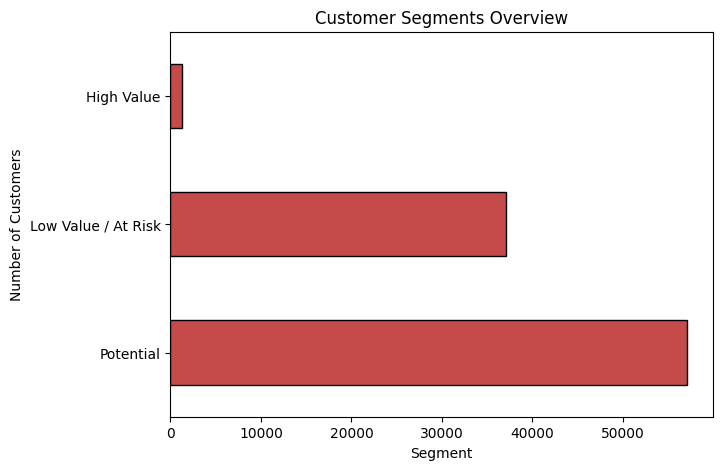

In [27]:
simple_counts = rfm['Simple_Segment'].value_counts()
simple_counts.plot(kind='barh', figsize=(7,5), color = "#c54a4a", edgecolor='black')
plt.title('Customer Segments Overview')
plt.ylabel('Number of Customers')
plt.xlabel('Segment')
plt.xticks(rotation=0)
plt.show()


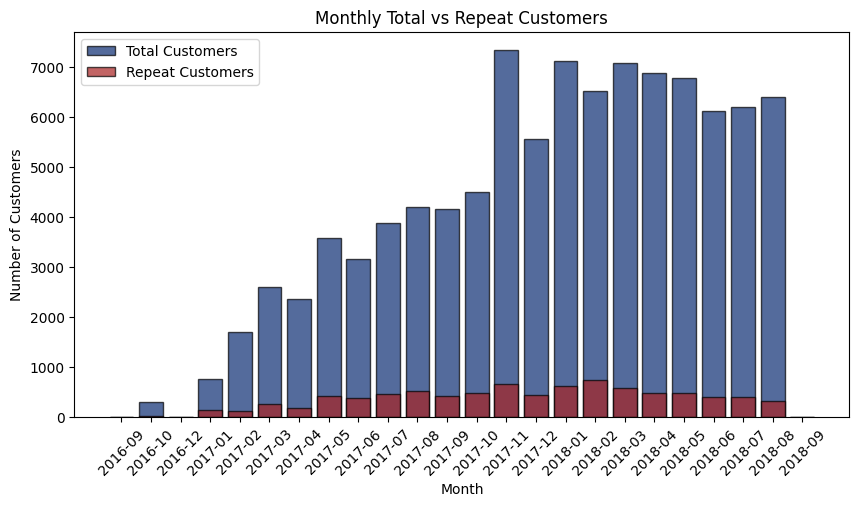

In [28]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

customer_orders = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_orders.columns = ['customer_unique_id', 'total_orders']

df = df.merge(customer_orders, on='customer_unique_id', how='left')
df['is_repeat'] = df['total_orders'] > 1

monthly_repeat = df.groupby('order_month').agg(
    total_customers=('customer_unique_id', 'nunique'),
    repeat_customers=('is_repeat', 'sum')
).reset_index()

# Graph 1: Monthly total vs repeat customers (Grouped Bar)
plt.figure(figsize=(10,5))
plt.bar(monthly_repeat['order_month'].astype(str), monthly_repeat['total_customers'], label='Total Customers', alpha=0.7, color = "#0B2D72", edgecolor='black')
plt.bar(monthly_repeat['order_month'].astype(str), monthly_repeat['repeat_customers'], label='Repeat Customers', alpha=0.7, color = "#A82323", edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.title('Monthly Total vs Repeat Customers')
plt.legend()
plt.show()

In [29]:
df['delivery_time_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

df['is_late'] = df['order_delivered_customer_date'] > df['order_estimated_delivery_date']

avg_delivery_time = df['delivery_time_days'].mean()
print(f"Average Delivery Time: {avg_delivery_time:.2f} days")

late_Delivery = df['is_late'].mean()*100
print(f"Late Delivery Percentage: {late_Delivery:.2f}%")

Average Delivery Time: 12.02 days
Late Delivery Percentage: 7.66%


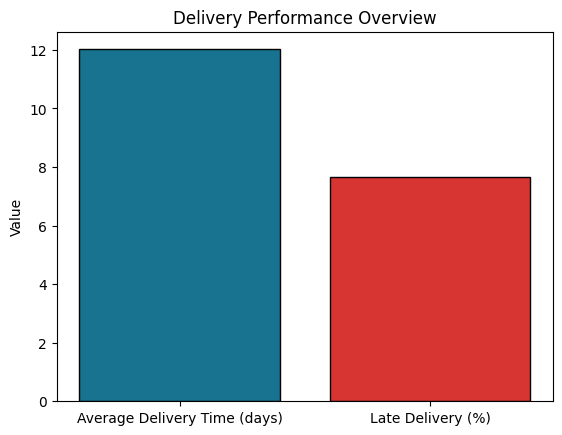

In [30]:
metrics = ['Average Delivery Time (days)', 'Late Delivery (%)']
values = [avg_delivery_time, late_Delivery]

plt.bar(metrics, values, color=["#17738f","#D63532"], edgecolor='black')
plt.title('Delivery Performance Overview')
plt.ylabel('Value')
plt.show()

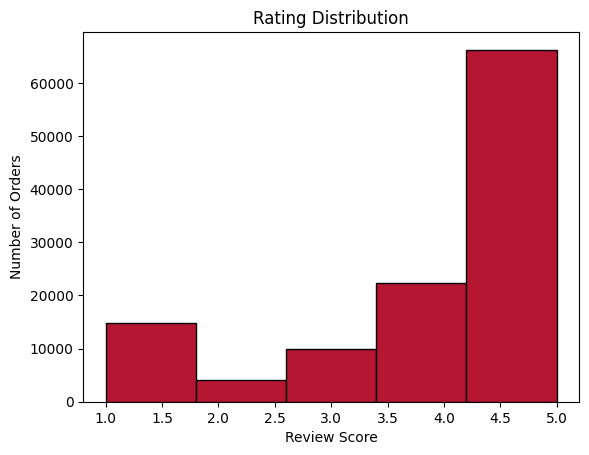

In [31]:
df['review_score'].hist(bins=5, edgecolor='black', color = "#b51732")
plt.xlabel('Review Score')
plt.ylabel('Number of Orders')
plt.title('Rating Distribution')
plt.grid(False)
plt.show()

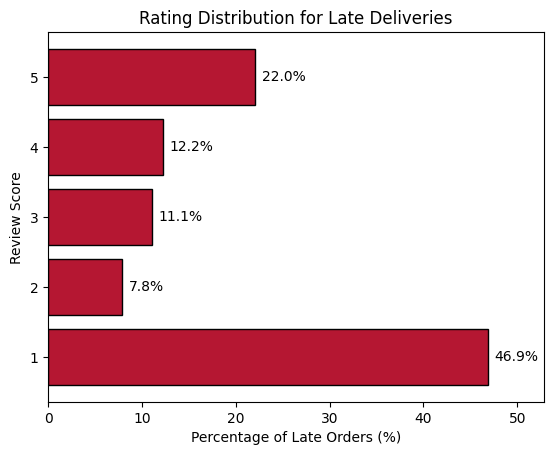

In [32]:
late_orders = df[df['is_late'] == 1]
late_pct = late_orders['review_score'].value_counts(normalize=True).sort_index() * 100
plt.barh(late_pct.index, late_pct.values, color='#b51732', edgecolor='black')

plt.xlabel('Percentage of Late Orders (%)')
plt.ylabel('Review Score')
plt.title('Rating Distribution for Late Deliveries')


plt.bar_label(plt.gca().containers[0], fmt='%.1f%%', padding=5)
plt.xlim(0, max(late_pct.values) + 6)
plt.show()
plt.show()

# 📌 Executive Summary – Olist E-Commerce Analysis

## 🎯 Objective
Conduct an end-to-end business analysis on the Olist Brazilian E-Commerce dataset to extract actionable insights related to sales growth, customer behavior, delivery performance, and retention.

---

## 📈 Key Findings

### 1️⃣ Revenue Growth
- Sales show growth from 2016 to 2018.

### 2️⃣ Customer Behavior
- ~96% customers are one-time buyers.

### 3️⃣ Customer Segmentation (RFM)
- A small segment of High-Value customers contributes to revenue.
- A large portion of customers fall into Potential or At-Risk categories.

### 4️⃣ Delivery Performance
- Average Delivery Time: 12.02 days.
- Late Delivery Percentage: 7.66%.
- Late deliveries are strongly associated with low (1-star) reviews.


## 💡 Business Recommendations

- Implement loyalty programs to increase repeat purchases.
- Improve delivery monitoring.
- Launch targeted campaigns for high-value customers.
- Re-engage at-risk customers through promotions and incentives.
- Monitor seller performance to maintain service quality.

---

## Conclusion

This end-to-end analysis highlights clear opportunities for revenue growth and operational improvement. 
While sales have grown steadily, customer retention remains a major opportunity, with a high percentage of one-time buyers. 
Improving delivery performance and targeting high-value and at-risk segments with personalized strategies can significantly enhance long-term profitability. 

Overall, the insights demonstrate how data-driven decision-making can directly impact customer satisfaction, retention, and business growth.